# ============================================================
# INDIAN STARTUP FUNDING ANALYSIS
# Data Analyst Portfolio Project
# ============================================================


In [2]:
# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

from collections import Counter



In [7]:
# ------------------------------------------------------------
# 2. PROJECT CONFIGURATION
# ------------------------------------------------------------

FILE_PATH = r"C:\Users\Nimesh\Desktop\Python\Recent Funding Rounds Indian Startups 2026\Recently Funded Startups In India 2026.csv"

OUTPUT_DIR = "startup_analysis_output"

CHART_DIR = os.path.join(OUTPUT_DIR, "charts")

TABLE_DIR = os.path.join(OUTPUT_DIR, "tables")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)


In [8]:
# ------------------------------------------------------------
# 3. LOAD DATA
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INDIAN STARTUP FUNDING ANALYSIS")
print("=" * 70)

df = pd.read_csv(FILE_PATH)

print("\nDataset loaded successfully.")

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")



INDIAN STARTUP FUNDING ANALYSIS

Dataset loaded successfully.
Rows    : 100
Columns : 7


In [9]:
# ------------------------------------------------------------
# 4. INITIAL DATA INSPECTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
print(df.head())

print("\nLast 5 Records:")
print(df.tail())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
print(df.info())



DATASET OVERVIEW

Column Names:
['Name', 'Website', 'Industry', 'Country', 'Funding Amount (USD)', 'Funding Type', 'Last Funding Date']

First 5 Records:
                  Name             Website  \
0            EarthSync        earthsync.io   
1            4baseCare       4basecare.com   
2      Cava Athleisure  cavaathleisure.com   
3             JuniorGo         juniorgo.in   
4  Entellus Industries     entellusind.com   

                                            Industry Country  \
0  Energy, Analytics, Artificial Intelligence, B2...   India   
1  Healthcare, Artificial Intelligence, B2B Softw...   India   
2  Fashion, Wellness, Consumer Goods, E-commerce,...   India   
3           Education, Finance, Personal Development   India   
4  Materials, Automotive, Electronics, EV, Manufa...   India   

  Funding Amount (USD) Funding Type Last Funding Date  
0           $1,000,000     Pre-Seed     February 2026  
1           $9,803,025     Series B     February 2026  
2           $4,

In [10]:
# ------------------------------------------------------------
# 5. DATA QUALITY CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

# Missing values
missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_report = pd.DataFrame({
    "Missing_Values": missing_values,
    "Missing_Percentage": missing_percentage
})

print("\nMissing Value Report:")
print(missing_report)

missing_report.to_csv(
    os.path.join(TABLE_DIR, "missing_value_report.csv")
)


# Duplicate records
duplicate_count = df.duplicated().sum()

print(f"\nDuplicate Records: {duplicate_count}")


# Duplicate startup names
duplicate_names = df["Name"].duplicated().sum()

print(f"Duplicate Startup Names: {duplicate_names}")



DATA QUALITY CHECK

Missing Value Report:
                      Missing_Values  Missing_Percentage
Name                               0                 0.0
Website                            0                 0.0
Industry                           0                 0.0
Country                            0                 0.0
Funding Amount (USD)              13                13.0
Funding Type                       0                 0.0
Last Funding Date                  0                 0.0

Duplicate Records: 0
Duplicate Startup Names: 0


In [11]:
# ------------------------------------------------------------
# 6. CLEAN COLUMN NAMES
# ------------------------------------------------------------

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

print("\nCleaned Column Names:")
print(df.columns.tolist())




Cleaned Column Names:
['name', 'website', 'industry', 'country', 'funding_amount_usd', 'funding_type', 'last_funding_date']


In [13]:
# ------------------------------------------------------------
# 7. CLEAN STARTUP NAMES
# ------------------------------------------------------------

df["name"] = (
    df["name"]
    .astype(str)
    .str.strip()
)

df["industry"] = (
    df["industry"]
    .astype(str)
    .str.strip()
)

df["funding_type"] = (
    df["funding_type"]
    .astype(str)
    .str.strip()
)


In [14]:
# ------------------------------------------------------------
# 8. CLEAN FUNDING AMOUNT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FUNDING AMOUNT CLEANING")
print("=" * 70)

print("\nOriginal Funding Amount Examples:")
print(df["funding_amount_usd"].head(10))


def clean_funding_amount(value):

    if pd.isna(value):
        return np.nan

    value = str(value)

    # Remove dollar signs
    value = value.replace("$", "")

    # Remove commas
    value = value.replace(",", "")

    # Remove spaces
    value = value.strip()

    # Handle values such as "-" or "N/A"
    if value.lower() in [
        "",
        "nan",
        "none",
        "n/a",
        "na",
        "-"
    ]:
        return np.nan

    try:
        return float(value)

    except ValueError:
        return np.nan


df["funding_amount"] = (
    df["funding_amount_usd"]
    .apply(clean_funding_amount)
)


print("\nCleaned Funding Amount:")
print(df["funding_amount"].head(10))



FUNDING AMOUNT CLEANING

Original Funding Amount Examples:
0    $1,000,000
1    $9,803,025
2    $4,353,085
3           NaN
4    $5,446,125
5           NaN
6    $3,534,664
7           NaN
8    $2,728,575
9    $2,396,295
Name: funding_amount_usd, dtype: str

Cleaned Funding Amount:
0    1000000.0
1    9803025.0
2    4353085.0
3          NaN
4    5446125.0
5          NaN
6    3534664.0
7          NaN
8    2728575.0
9    2396295.0
Name: funding_amount, dtype: float64


In [16]:
# ------------------------------------------------------------
# 9. CLEAN FUNDING DATE
# ------------------------------------------------------------

df["last_funding_date"] = pd.to_datetime(
    df["last_funding_date"],
    errors="coerce",
    format="mixed"
)

print("\nFunding Date Range:")

print("Start:", df["last_funding_date"].min())
print("End:", df["last_funding_date"].max())

# Count invalid/missing dates
invalid_dates = df["last_funding_date"].isna().sum()

print("Invalid/Missing Funding Dates:", invalid_dates)


Funding Date Range:
Start: 2026-01-01 00:00:00
End: 2026-02-01 00:00:00
Invalid/Missing Funding Dates: 0


In [17]:
# ------------------------------------------------------------
# 10. CREATE DATE ATTRIBUTES
# ------------------------------------------------------------

df["funding_year"] = (
    df["last_funding_date"]
    .dt.year
)

df["funding_month"] = (
    df["last_funding_date"]
    .dt.month
)

df["funding_month_name"] = (
    df["last_funding_date"]
    .dt.month_name()
)

df["funding_quarter"] = (
    df["last_funding_date"]
    .dt.quarter
)


In [18]:
# ------------------------------------------------------------
# 11. BASIC DATASET PROFILE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET PROFILE")
print("=" * 70)

print(
    f"\nTotal Startups: {df['name'].nunique():,}"
)

print(
    f"Total Records: {len(df):,}"
)

print(
    f"Unique Industries: {df['industry'].nunique():,}"
)

print(
    f"Unique Funding Types: {df['funding_type'].nunique():,}"
)

print(
    f"Unique Countries: {df['country'].nunique():,}"
)

print(
    f"Funding Records with Amount: "
    f"{df['funding_amount'].notna().sum():,}"
)

print(
    f"Funding Records without Amount: "
    f"{df['funding_amount'].isna().sum():,}"
)



DATASET PROFILE

Total Startups: 100
Total Records: 100
Unique Industries: 92
Unique Funding Types: 10
Unique Countries: 1
Funding Records with Amount: 87
Funding Records without Amount: 13


In [19]:
# ------------------------------------------------------------
# 12. KEY KPI CALCULATIONS
# ------------------------------------------------------------

total_startups = df["name"].nunique()

total_funding = df["funding_amount"].sum()

average_funding = df["funding_amount"].mean()

median_funding = df["funding_amount"].median()

largest_funding = df["funding_amount"].max()

funded_records = df["funding_amount"].notna().sum()

funding_coverage = (
    funded_records / len(df) * 100
)


print("\n" + "=" * 70)
print("KEY PERFORMANCE INDICATORS")
print("=" * 70)

print(
    f"\nTotal Startups       : {total_startups:,}"
)

print(
    f"Total Funding       : ${total_funding:,.2f}"
)

print(
    f"Average Funding     : ${average_funding:,.2f}"
)

print(
    f"Median Funding      : ${median_funding:,.2f}"
)

print(
    f"Largest Funding     : ${largest_funding:,.2f}"
)

print(
    f"Funding Coverage    : {funding_coverage:.2f}%"
)




KEY PERFORMANCE INDICATORS

Total Startups       : 100
Total Funding       : $1,315,987,751.00
Average Funding     : $15,126,295.99
Median Funding      : $3,000,000.00
Largest Funding     : $304,527,929.00
Funding Coverage    : 87.00%


In [20]:
# ------------------------------------------------------------
# 13. FUNDING DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FUNDING DISTRIBUTION")
print("=" * 70)

print("\nFunding Statistics:")

print(
    df["funding_amount"]
    .describe()
)



FUNDING DISTRIBUTION

Funding Statistics:
count    8.700000e+01
mean     1.512630e+07
std      4.049265e+07
min      8.294100e+04
25%      1.000000e+06
50%      3.000000e+06
75%      9.901512e+06
max      3.045279e+08
Name: funding_amount, dtype: float64


In [21]:

# ------------------------------------------------------------
# 14. TOP 10 STARTUPS BY FUNDING
# ------------------------------------------------------------

top_10_startups = (
    df[
        [
            "name",
            "industry",
            "funding_type",
            "funding_amount"
        ]
    ]
    .dropna(subset=["funding_amount"])
    .sort_values(
        "funding_amount",
        ascending=False
    )
    .head(10)
)

print("\n" + "=" * 70)
print("TOP 10 STARTUPS BY FUNDING")
print("=" * 70)

print(top_10_startups.to_string(index=False))

top_10_startups.to_csv(
    os.path.join(
        TABLE_DIR,
        "top_10_startups_by_funding.csv"
    ),
    index=False
)



TOP 10 STARTUPS BY FUNDING
                        name                                                                           industry             funding_type  funding_amount
Aditya Birla Housing Finance                                                               Finance, Real Estate           Private Equity     304527929.0
                    CleanMax                                                                Energy, Environment           Private Equity     165434178.0
                  GREW Solar                                       Energy, Electronics, Hardware, Manufacturing           Private Equity     115738738.0
         Radiance Renewables                                       Energy, Construction, Environment, Utilities           Private Equity     100000000.0
             Arya Collateral                                       Agriculture, Finance, Logistics, Marketplace                 Series D      80584611.0
             The Whole Truth Food and Beverage, Wellne

In [22]:
# ------------------------------------------------------------
# 15. FUNDING BY FUNDING TYPE
# ------------------------------------------------------------

funding_stage_analysis = (
    df.groupby("funding_type")
    .agg(
        Startup_Count=("name", "nunique"),
        Total_Funding=("funding_amount", "sum"),
        Average_Funding=("funding_amount", "mean"),
        Median_Funding=("funding_amount", "median")
    )
    .sort_values(
        "Total_Funding",
        ascending=False
    )
)

print("\n" + "=" * 70)
print("FUNDING BY FUNDING TYPE")
print("=" * 70)

print(
    funding_stage_analysis
    .to_string()
)

funding_stage_analysis.to_csv(
    os.path.join(
        TABLE_DIR,
        "funding_by_stage.csv"
    )
)



FUNDING BY FUNDING TYPE
                          Startup_Count  Total_Funding  Average_Funding  Median_Funding
funding_type                                                                           
Private Equity                        7    705091478.0     1.410183e+08     115738738.0
Series A                             16    169259850.0     1.128399e+07       8823156.0
Series D                              3    141584611.0     4.719487e+07      51000000.0
Series C                              4     86144311.0     2.153608e+07      26414958.5
Seed                                 44     82884549.0     2.125245e+06       1985210.0
Series B                              6     59751837.0     1.195037e+07       9803025.0
Venture - Series Unknown              6     43321240.0     8.664248e+06       2600000.0
Series E                              1     21918324.0     2.191832e+07      21918324.0
Pre-Seed                             12      4941551.0     5.490612e+05        221366.0
Convert

In [23]:
# ------------------------------------------------------------
# 16. FUNDING STAGE DISTRIBUTION
# ------------------------------------------------------------

stage_counts = (
    df["funding_type"]
    .value_counts()
)

print("\nStartup Count by Funding Stage:")

print(stage_counts)



Startup Count by Funding Stage:
funding_type
Seed                        44
Series A                    16
Pre-Seed                    12
Private Equity               7
Series B                     6
Venture - Series Unknown     6
Series C                     4
Series D                     3
Series E                     1
Convertible Note             1
Name: count, dtype: int64


In [24]:
# ------------------------------------------------------------
# 17. INDUSTRY ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INDUSTRY ANALYSIS")
print("=" * 70)


# Since each startup can contain multiple industries,
# split the industry column.

industry_df = (
    df[
        [
            "name",
            "industry",
            "funding_amount"
        ]
    ]
    .dropna(subset=["industry"])
    .copy()
)

industry_df["industry"] = (
    industry_df["industry"]
    .str.split(",")
)

industry_df = industry_df.explode(
    "industry"
)

industry_df["industry"] = (
    industry_df["industry"]
    .str.strip()
)


# Industry startup count
industry_startups = (
    industry_df
    .groupby("industry")["name"]
    .nunique()
    .sort_values(
        ascending=False
    )
)

print("\nTop Industries by Startup Count:")

print(
    industry_startups.head(20)
)


# Industry funding
industry_funding = (
    industry_df
    .groupby("industry")
    .agg(
        Startup_Count=("name", "nunique"),
        Total_Funding=("funding_amount", "sum"),
        Average_Funding=("funding_amount", "mean")
    )
    .sort_values(
        "Total_Funding",
        ascending=False
    )
)

print("\nTop Industries by Funding:")

print(
    industry_funding
    .head(20)
    .to_string()
)

industry_funding.to_csv(
    os.path.join(
        TABLE_DIR,
        "industry_funding_analysis.csv"
    )
)



INDUSTRY ANALYSIS

Top Industries by Startup Count:
industry
Consumer Goods             24
E-commerce                 24
B2B Software               23
Retail                     19
Hardware                   18
Manufacturing              17
Finance                    16
Wellness                   15
Artificial Intelligence    14
Healthcare                 13
Food and Beverage          12
FinTech                     9
Marketplace                 8
Electronics                 8
Energy                      7
Fashion                     7
Data                        6
Automotive                  6
Analytics                   6
Environment                 6
Name: name, dtype: int64

Top Industries by Funding:
                   Startup_Count  Total_Funding  Average_Funding
industry                                                        
Finance                       16    475263666.0     3.960531e+07
Energy                         7    390943369.0     5.584905e+07
Real Estate              

In [25]:
# ------------------------------------------------------------
# 18. MOST COMMON INDUSTRIES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MOST COMMON INDUSTRIES")
print("=" * 70)

for industry, count in industry_startups.head(15).items():

    print(
        f"{industry:<35} {count:>5} startups"
    )



MOST COMMON INDUSTRIES
Consumer Goods                         24 startups
E-commerce                             24 startups
B2B Software                           23 startups
Retail                                 19 startups
Hardware                               18 startups
Manufacturing                          17 startups
Finance                                16 startups
Wellness                               15 startups
Artificial Intelligence                14 startups
Healthcare                             13 startups
Food and Beverage                      12 startups
FinTech                                 9 startups
Marketplace                             8 startups
Electronics                             8 startups
Energy                                  7 startups


In [26]:
# ------------------------------------------------------------
# 19. FUNDING CONCENTRATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FUNDING CONCENTRATION")
print("=" * 70)

if total_funding > 0:

    top_10_funding = (
        top_10_startups["funding_amount"]
        .sum()
    )

    top_10_share = (
        top_10_funding /
        total_funding *
        100
    )

    print(
        f"\nTop 10 startups account for "
        f"{top_10_share:.2f}% of total funding."
    )



FUNDING CONCENTRATION

Top 10 startups account for 70.95% of total funding.


In [27]:
# ------------------------------------------------------------
# 20. MONTHLY FUNDING ANALYSIS
# ------------------------------------------------------------

monthly_analysis = (
    df.groupby(
        [
            "funding_year",
            "funding_month",
            "funding_month_name"
        ]
    )
    .agg(
        Startup_Count=("name", "nunique"),
        Total_Funding=("funding_amount", "sum"),
        Average_Funding=("funding_amount", "mean")
    )
    .reset_index()
    .sort_values(
        [
            "funding_year",
            "funding_month"
        ]
    )
)

print("\n" + "=" * 70)
print("MONTHLY FUNDING ANALYSIS")
print("=" * 70)

print(
    monthly_analysis.to_string(
        index=False
    )
)

monthly_analysis.to_csv(
    os.path.join(
        TABLE_DIR,
        "monthly_funding_analysis.csv"
    ),
    index=False
)



MONTHLY FUNDING ANALYSIS
 funding_year  funding_month funding_month_name  Startup_Count  Total_Funding  Average_Funding
         2026              1            January             31    214102218.0     7.136741e+06
         2026              2           February             69   1101885533.0     1.933133e+07


In [28]:
# ------------------------------------------------------------
# 21. QUARTERLY ANALYSIS
# ------------------------------------------------------------

quarterly_analysis = (
    df.groupby(
        [
            "funding_year",
            "funding_quarter"
        ]
    )
    .agg(
        Startup_Count=("name", "nunique"),
        Total_Funding=("funding_amount", "sum"),
        Average_Funding=("funding_amount", "mean")
    )
    .reset_index()
)

print("\n" + "=" * 70)
print("QUARTERLY FUNDING ANALYSIS")
print("=" * 70)

print(
    quarterly_analysis.to_string(
        index=False
    )
)



QUARTERLY FUNDING ANALYSIS
 funding_year  funding_quarter  Startup_Count  Total_Funding  Average_Funding
         2026                1            100   1315987751.0     1.512630e+07


In [29]:
# ------------------------------------------------------------
# 22. FUNDING BY COUNTRY
# ------------------------------------------------------------

country_analysis = (
    df.groupby("country")
    .agg(
        Startup_Count=("name", "nunique"),
        Total_Funding=("funding_amount", "sum"),
        Average_Funding=("funding_amount", "mean")
    )
    .sort_values(
        "Total_Funding",
        ascending=False
    )
)

print("\n" + "=" * 70)
print("COUNTRY ANALYSIS")
print("=" * 70)

print(
    country_analysis.to_string()
)



COUNTRY ANALYSIS
         Startup_Count  Total_Funding  Average_Funding
country                                               
India              100   1.315988e+09     1.512630e+07


In [30]:
# ------------------------------------------------------------
# 23. LARGE FUNDING DEALS
# ------------------------------------------------------------

funding_threshold = (
    df["funding_amount"]
    .quantile(0.75)
)

large_deals = (
    df[
        df["funding_amount"]
        >= funding_threshold
    ]
    .sort_values(
        "funding_amount",
        ascending=False
    )
)

print("\n" + "=" * 70)
print("LARGE FUNDING DEALS")
print("=" * 70)

print(
    f"\n75th Percentile Funding: "
    f"${funding_threshold:,.2f}"
)

print(
    large_deals[
        [
            "name",
            "industry",
            "funding_type",
            "funding_amount"
        ]
    ]
    .to_string(index=False)
)



LARGE FUNDING DEALS

75th Percentile Funding: $9,901,512.50
                        name                                                                           industry             funding_type  funding_amount
Aditya Birla Housing Finance                                                               Finance, Real Estate           Private Equity     304527929.0
                    CleanMax                                                                Energy, Environment           Private Equity     165434178.0
                  GREW Solar                                       Energy, Electronics, Hardware, Manufacturing           Private Equity     115738738.0
         Radiance Renewables                                       Energy, Construction, Environment, Utilities           Private Equity     100000000.0
             Arya Collateral                                       Agriculture, Finance, Logistics, Marketplace                 Series D      80584611.0
             The Whol

In [32]:
# ------------------------------------------------------------
# 24. FUNDING STAGE × INDUSTRY
# ------------------------------------------------------------

# Create a clean dataframe containing only required columns
stage_industry_df = df[[
    "industry",
    "funding_type"
]].copy()

# Remove missing values
stage_industry_df = stage_industry_df.dropna(
    subset=["industry", "funding_type"]
)

# Remove leading/trailing spaces
stage_industry_df["industry"] = (
    stage_industry_df["industry"]
    .astype(str)
    .str.strip()
)

stage_industry_df["funding_type"] = (
    stage_industry_df["funding_type"]
    .astype(str)
    .str.strip()
)

# Create cross-tabulation
stage_industry = pd.crosstab(
    stage_industry_df["industry"],
    stage_industry_df["funding_type"]
)

print("\n" + "=" * 70)
print("INDUSTRY × FUNDING STAGE")
print("=" * 70)

print(stage_industry.head(20))


INDUSTRY × FUNDING STAGE
funding_type                                        Convertible Note  \
industry                                                               
Accounting, Finance, Professional Services                         0   
Aerospace, Aviation, Government, Hardware, Manu...                 0   
Aerospace, Government, Hardware, Manufacturing,...                 0   
Aerospace, Hardware                                                0   
Aerospace, Hardware, Robotics                                      0   
Agriculture, E-commerce, Marketplace                               0   
Agriculture, Environment                                           0   
Agriculture, Finance, Logistics, Marketplace                       0   
Analytics, 3D, Artificial Intelligence, B2B Sof...                 0   
Artificial Intelligence, Analytics, B2B Softwar...                 0   
Artificial Intelligence, B2B Software, Data, Ma...                 0   
Artificial Intelligence, B2B Software,

In [33]:
# ------------------------------------------------------------
# 25. STARTUPS WITH MULTIPLE INDUSTRIES
# ------------------------------------------------------------

df["industry_count"] = (
    df["industry"]
    .str.split(",")
    .apply(
        lambda x:
        len(x)
        if isinstance(x, list)
        else 0
    )
)

multi_industry = (
    df[
        df["industry_count"] > 1
    ]
    .sort_values(
        "industry_count",
        ascending=False
    )
)

print("\n" + "=" * 70)
print("MULTI-INDUSTRY STARTUPS")
print("=" * 70)

print(
    multi_industry[
        [
            "name",
            "industry",
            "industry_count"
        ]
    ]
    .head(20)
    .to_string(index=False)
)



MULTI-INDUSTRY STARTUPS
                    name                                                                                           industry  industry_count
                AquaAirX         Drones, Artificial Intelligence, B2B Software, Cloud Computing, Hardware, Marine, Robotics               7
                  EyeROV               Drones, Artificial Intelligence, Analytics, B2B Software, Hardware, Marine, Robotics               7
             Slurrp Farm Food and Beverage, Wellness, Consumer Goods, E-commerce, Family, Nutrition and Supplements, Retail               7
WellWith India Pvt. Ltd. Nutrition and Supplements, Wellness, Beauty, Consumer Goods, E-commerce, Food and Beverage, Retail               7
                Heliware                        Analytics, 3D, Artificial Intelligence, B2B Software, Cloud Computing, Data               6
            Showroom B2B                     Fashion, Artificial Intelligence, B2B Software, Logistics, Marketplace, Retail            

In [34]:
# ------------------------------------------------------------
# 26. INDUSTRY FUNDING SHARE
# ------------------------------------------------------------

industry_share = (
    industry_funding[
        "Total_Funding"
    ]
    / industry_funding[
        "Total_Funding"
    ].sum()
    * 100
)

industry_funding[
    "Funding_Share_%"
] = industry_share

print("\n" + "=" * 70)
print("INDUSTRY FUNDING SHARE")
print("=" * 70)

print(
    industry_funding[
        [
            "Startup_Count",
            "Total_Funding",
            "Funding_Share_%"
        ]
    ]
    .head(15)
    .to_string()
)



INDUSTRY FUNDING SHARE
                Startup_Count  Total_Funding  Funding_Share_%
industry                                                     
Finance                    16    475263666.0        11.605132
Energy                      7    390943369.0         9.546174
Real Estate                 4    340829299.0         8.322473
Environment                 6    289434178.0         7.067491
Manufacturing              17    217755318.0         5.317215
Hardware                   18    152690371.0         3.728440
E-commerce                 24    151408165.0         3.697130
Electronics                 8    135987987.0         3.320596
Marketplace                 8    129267701.0         3.156498
Agriculture                 4    117584611.0         2.871217
Consumer Goods             24    114207944.0         2.788764
B2B Software               23    108905411.0         2.659285
Construction                2    100221366.0         2.447236
Healthcare                 13    100009794.0  

In [35]:
# ------------------------------------------------------------
# 27. OUTLIER DETECTION USING IQR
# ------------------------------------------------------------

funding_clean = (
    df["funding_amount"]
    .dropna()
)

Q1 = funding_clean.quantile(0.25)

Q3 = funding_clean.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["funding_amount"] < lower_bound)
    |
    (df["funding_amount"] > upper_bound)
]

print("\n" + "=" * 70)
print("FUNDING OUTLIERS")
print("=" * 70)

print(
    f"\nLower Bound : ${lower_bound:,.2f}"
)

print(
    f"Upper Bound : ${upper_bound:,.2f}"
)

print(
    f"Outlier Records: {len(outliers)}"
)

print(
    outliers[
        [
            "name",
            "funding_type",
            "funding_amount"
        ]
    ]
    .sort_values(
        "funding_amount",
        ascending=False
    )
    .to_string(index=False)
)



FUNDING OUTLIERS

Lower Bound : $-12,352,268.75
Upper Bound : $23,253,781.25
Outlier Records: 10
                        name             funding_type  funding_amount
Aditya Birla Housing Finance           Private Equity     304527929.0
                    CleanMax           Private Equity     165434178.0
                  GREW Solar           Private Equity     115738738.0
         Radiance Renewables           Private Equity     100000000.0
             Arya Collateral                 Series D      80584611.0
             The Whole Truth                 Series D      51000000.0
                 JS AutoCast Venture - Series Unknown      32773634.0
           Easy Home Finance                 Series C      30000000.0
                  Supertails                 Series C      30000000.0
              Knight FinTech                 Series A      23600000.0


In [36]:
# ------------------------------------------------------------
# 28. FUNDING AMOUNT BY STAGE
# ------------------------------------------------------------

stage_order = [
    "Pre-Seed",
    "Seed",
    "Series A",
    "Series B",
    "Series C",
    "Series D",
    "Series E",
    "Series F",
    "Series G"
]

existing_stages = [
    stage for stage in stage_order
    if stage in df["funding_type"].unique()
]

stage_summary = (
    df[
        df["funding_type"]
        .isin(existing_stages)
    ]
    .groupby("funding_type")
    ["funding_amount"]
    .agg(
        ["count", "sum", "mean", "median"]
    )
)

stage_summary = (
    stage_summary
    .reindex(existing_stages)
)

print("\n" + "=" * 70)
print("FUNDING STAGE SUMMARY")
print("=" * 70)

print(stage_summary)



FUNDING STAGE SUMMARY
              count          sum          mean      median
funding_type                                              
Pre-Seed          9    4941551.0  5.490612e+05    221366.0
Seed             39   82884549.0  2.125245e+06   1985210.0
Series A         15  169259850.0  1.128399e+07   8823156.0
Series B          5   59751837.0  1.195037e+07   9803025.0
Series C          4   86144311.0  2.153608e+07  26414958.5
Series D          3  141584611.0  4.719487e+07  51000000.0
Series E          1   21918324.0  2.191832e+07  21918324.0


# ============================================================
# VISUAL ANALYSIS
# ============================================================


In [37]:
sns.set_theme(
    style="whitegrid"
)


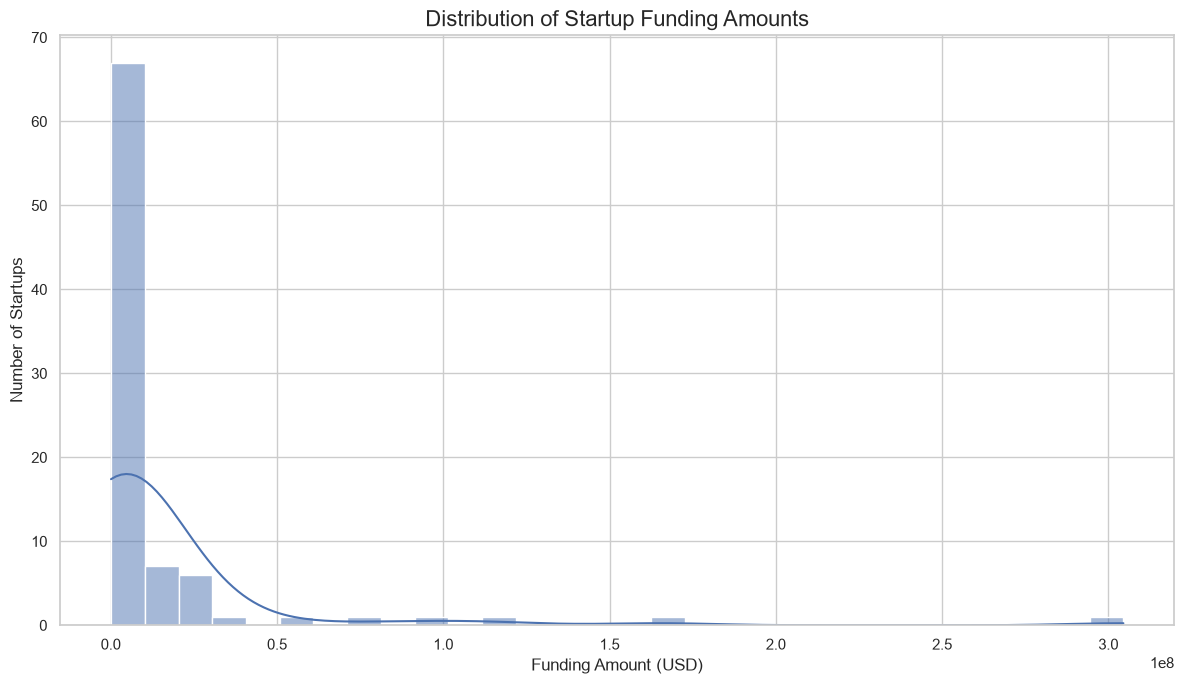

In [38]:
# ------------------------------------------------------------
# CHART 1 — FUNDING DISTRIBUTION
# ------------------------------------------------------------

plt.figure(
    figsize=(12, 7)
)

sns.histplot(
    df["funding_amount"],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Startup Funding Amounts",
    fontsize=16
)

plt.xlabel(
    "Funding Amount (USD)"
)

plt.ylabel(
    "Number of Startups"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "01_funding_distribution.png"
    ),
    dpi=300
)

plt.show()


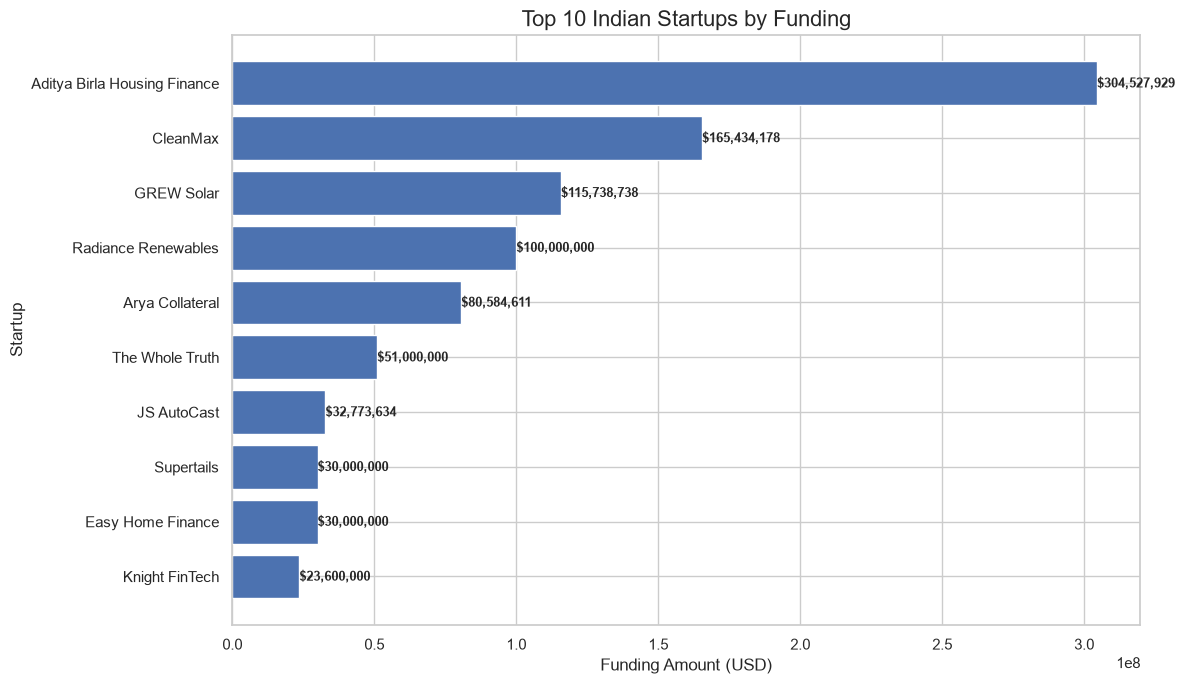

In [39]:
# ------------------------------------------------------------
# CHART 2 — TOP 10 STARTUPS
# ------------------------------------------------------------

plot_data = (
    top_10_startups
    .sort_values("funding_amount")
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    plot_data["name"],
    plot_data["funding_amount"]
)

plt.title(
    "Top 10 Indian Startups by Funding",
    fontsize=16
)

plt.xlabel("Funding Amount (USD)")
plt.ylabel("Startup")

# VALUE LABELS
for bar in bars:

    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "02_top_10_startups.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


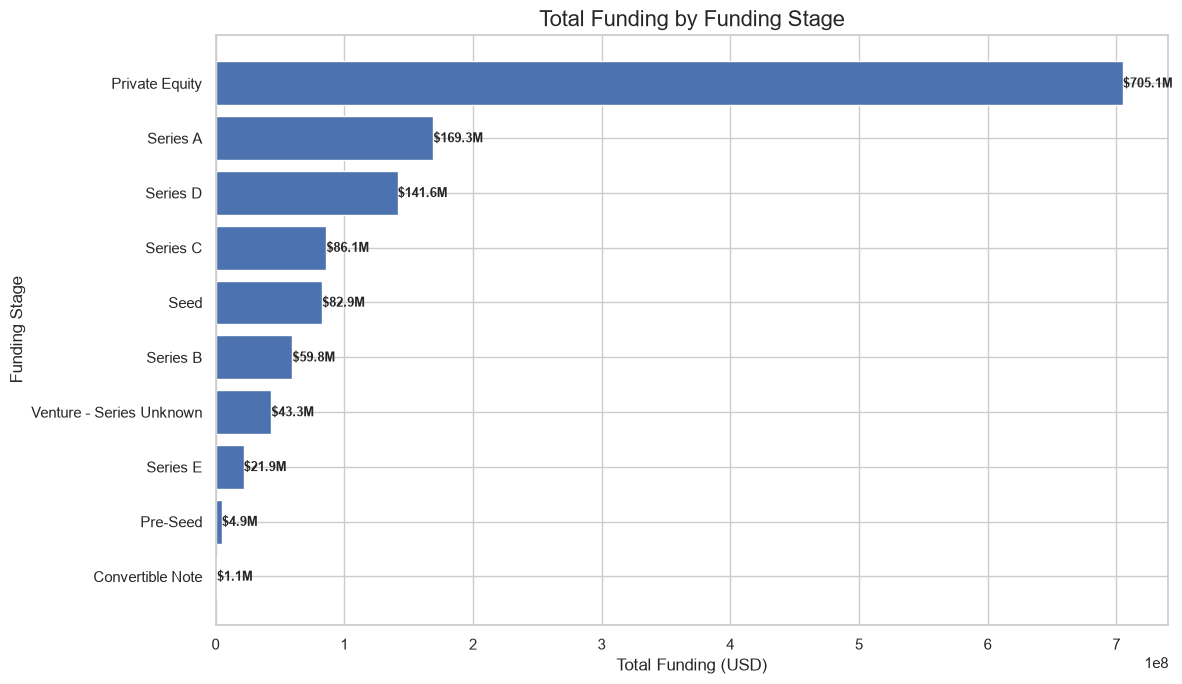

In [40]:
# ------------------------------------------------------------
# CHART 3 — FUNDING BY STAGE
# ------------------------------------------------------------

stage_plot = (
    funding_stage_analysis
    .sort_values("Total_Funding")
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    stage_plot.index,
    stage_plot["Total_Funding"]
)

plt.title(
    "Total Funding by Funding Stage",
    fontsize=16
)

plt.xlabel("Total Funding (USD)")
plt.ylabel("Funding Stage")

# VALUE LABELS
for bar in bars:

    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"${value/1e6:.1f}M",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "03_funding_by_stage.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


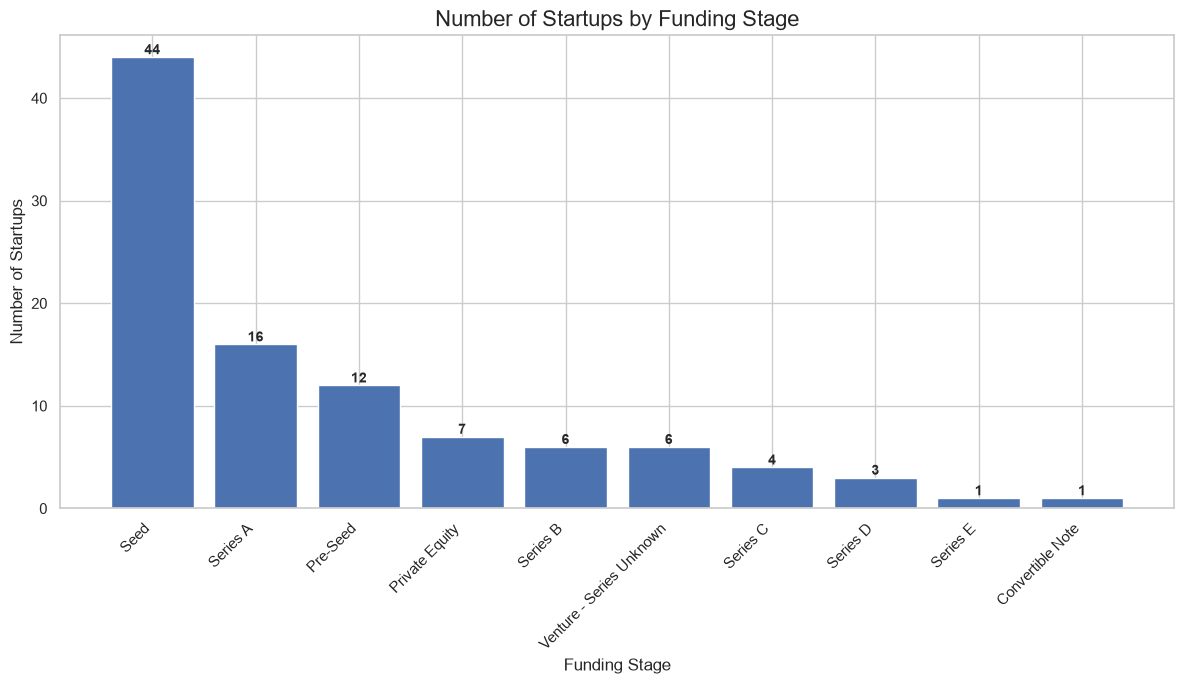

In [41]:
# ------------------------------------------------------------
# CHART 4 — STARTUPS BY FUNDING STAGE
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

bars = plt.bar(
    stage_counts.index,
    stage_counts.values
)

plt.title(
    "Number of Startups by Funding Stage",
    fontsize=16
)

plt.xlabel("Funding Stage")
plt.ylabel("Number of Startups")

plt.xticks(
    rotation=45,
    ha="right"
)

# VALUE LABELS ABOVE BARS
for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "04_startups_by_stage.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


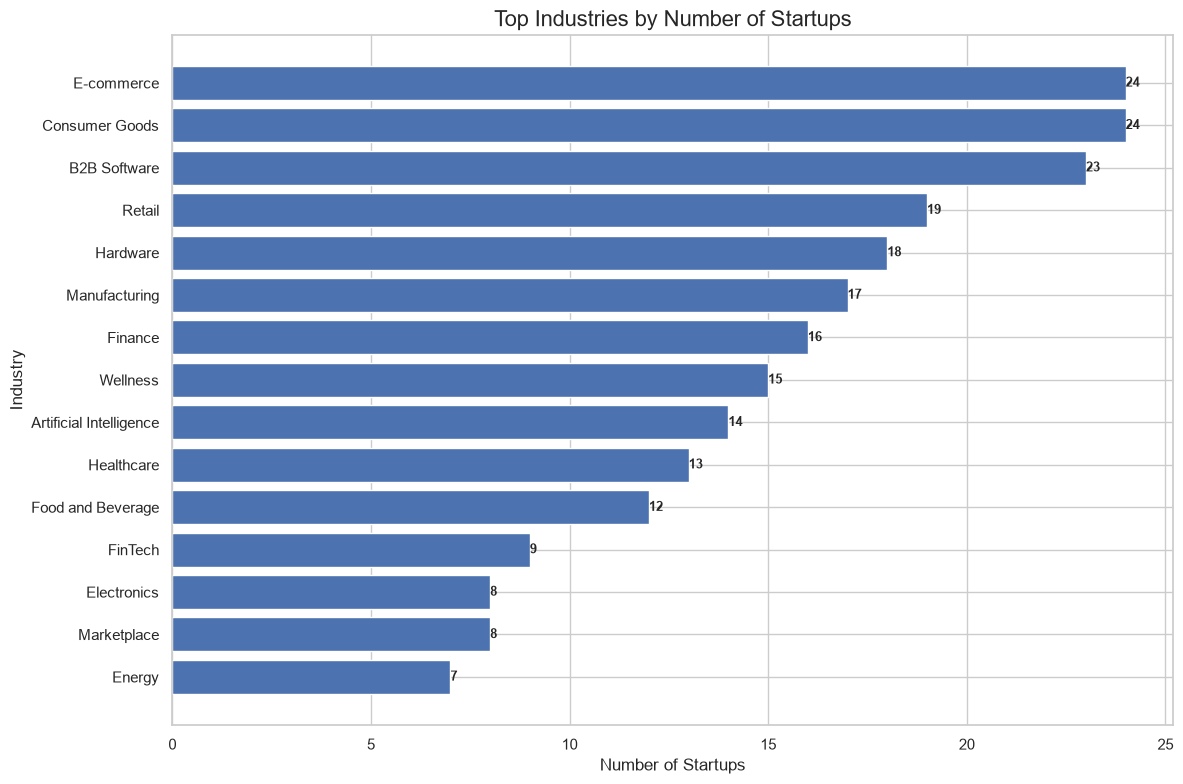

In [42]:

# ------------------------------------------------------------
# CHART 5 — TOP INDUSTRIES BY STARTUP COUNT
# ------------------------------------------------------------

top_industries = (
    industry_startups
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top_industries.index,
    top_industries.values
)

plt.title(
    "Top Industries by Number of Startups",
    fontsize=16
)

plt.xlabel("Number of Startups")
plt.ylabel("Industry")

# VALUE LABELS
for bar in bars:

    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value)}",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "05_top_industries_by_count.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


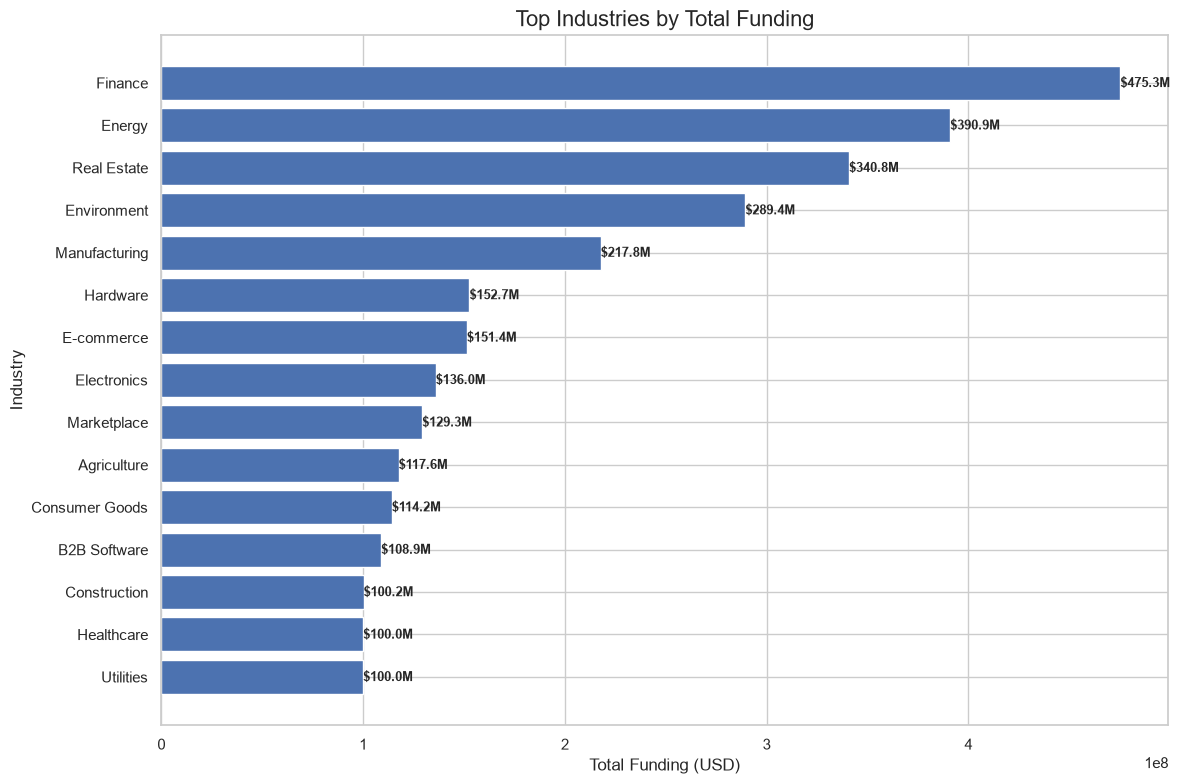

In [43]:

# ------------------------------------------------------------
# CHART 6 — TOP INDUSTRIES BY FUNDING
# ------------------------------------------------------------

top_industry_funding = (
    industry_funding
    .head(15)
    .sort_values("Total_Funding")
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top_industry_funding.index,
    top_industry_funding["Total_Funding"]
)

plt.title(
    "Top Industries by Total Funding",
    fontsize=16
)

plt.xlabel("Total Funding (USD)")
plt.ylabel("Industry")

# VALUE LABELS
for bar in bars:

    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"${value/1e6:.1f}M",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "06_top_industries_by_funding.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


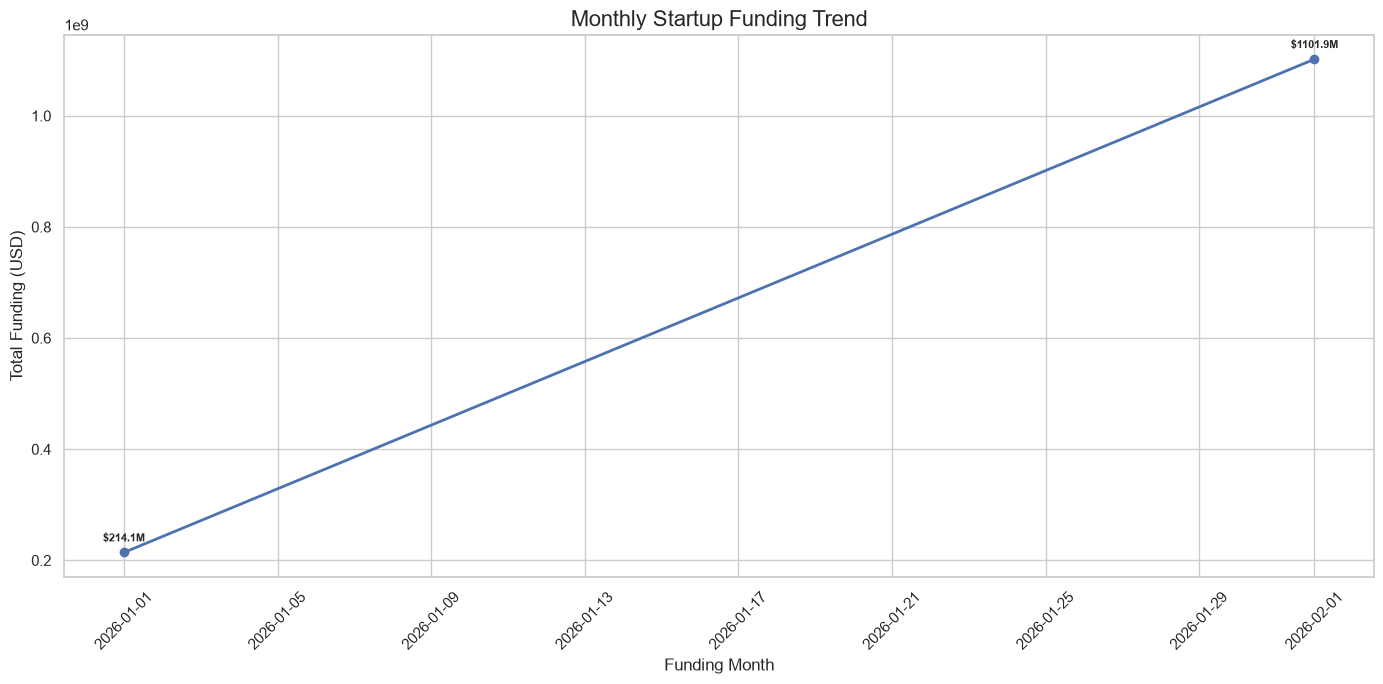

In [44]:
# ------------------------------------------------------------
# CHART 7 — MONTHLY FUNDING
# ------------------------------------------------------------

monthly_plot = monthly_analysis.copy()

monthly_plot["period"] = pd.to_datetime(
    monthly_plot["funding_year"].astype(str)
    + "-"
    + monthly_plot["funding_month"].astype(str)
    + "-01"
)

monthly_plot = (
    monthly_plot
    .sort_values("period")
)

plt.figure(figsize=(14, 7))

plt.plot(
    monthly_plot["period"],
    monthly_plot["Total_Funding"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Startup Funding Trend",
    fontsize=16
)

plt.xlabel("Funding Month")
plt.ylabel("Total Funding (USD)")

plt.xticks(rotation=45)

# VALUE LABELS ABOVE POINTS
for x, y in zip(
    monthly_plot["period"],
    monthly_plot["Total_Funding"]
):

    plt.annotate(
        f"${y/1e6:.1f}M",
        xy=(x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "07_monthly_funding_trend.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


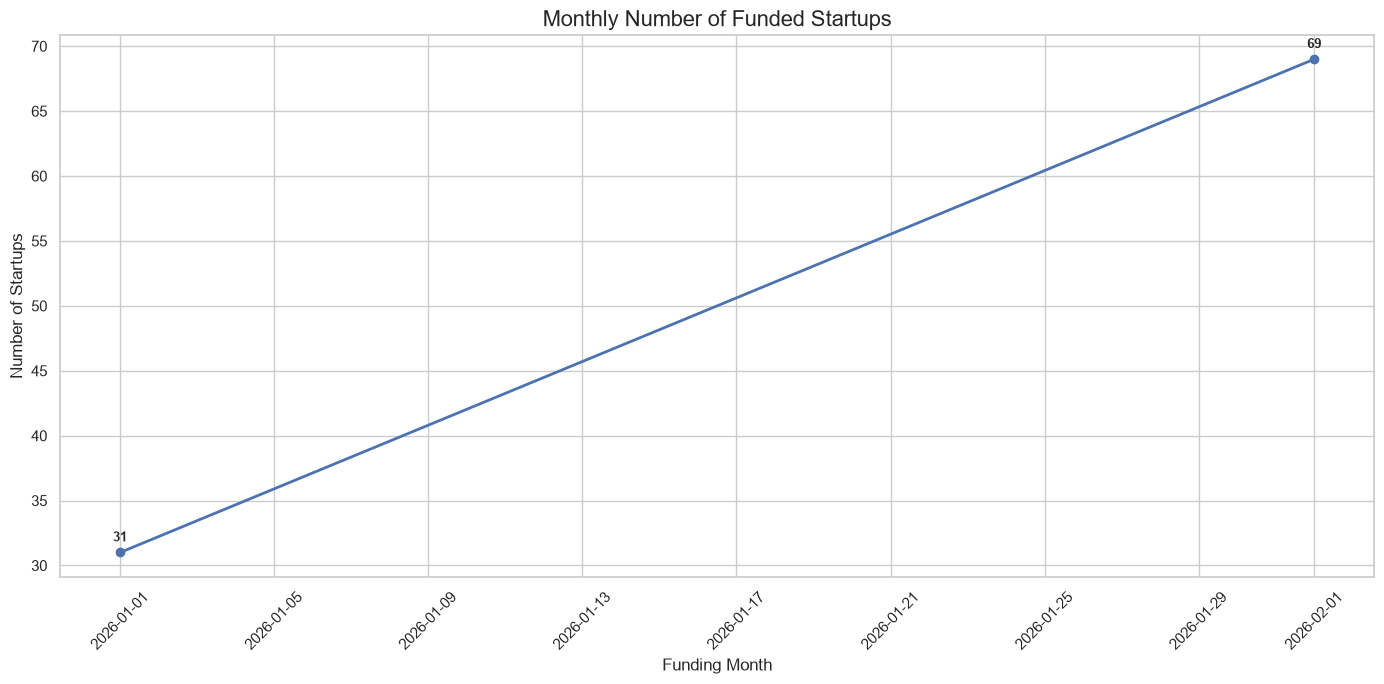

In [45]:
# ------------------------------------------------------------
# CHART 8 — MONTHLY STARTUP COUNT
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

plt.plot(
    monthly_plot["period"],
    monthly_plot["Startup_Count"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Number of Funded Startups",
    fontsize=16
)

plt.xlabel("Funding Month")
plt.ylabel("Number of Startups")

plt.xticks(rotation=45)

# VALUE LABELS ABOVE POINTS
for x, y in zip(
    monthly_plot["period"],
    monthly_plot["Startup_Count"]
):

    plt.annotate(
        f"{int(y)}",
        xy=(x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "08_monthly_startup_count.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


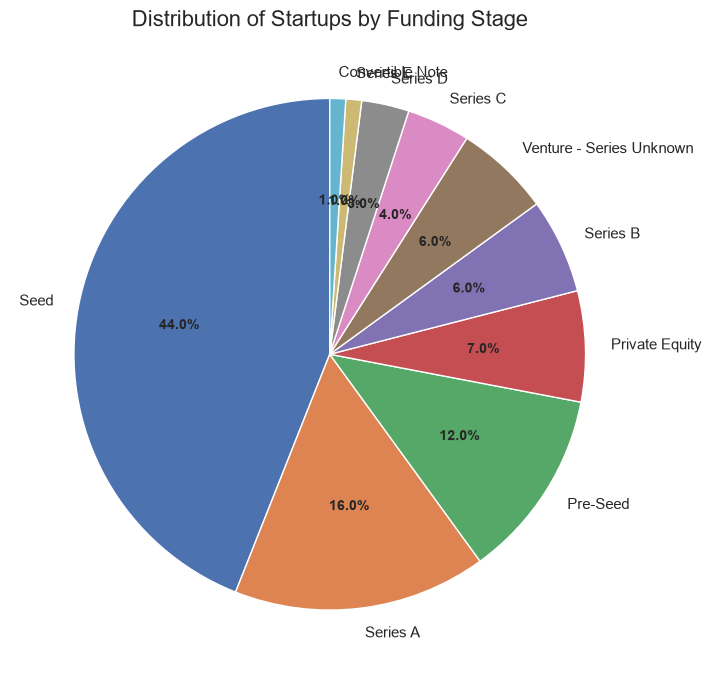

In [46]:
# ------------------------------------------------------------
# CHART 9 — FUNDING STAGE DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

wedges, texts, autotexts = plt.pie(
    stage_counts.values,
    labels=stage_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Distribution of Startups by Funding Stage",
    fontsize=16
)

# MAKE PERCENTAGES BOLD
for autotext in autotexts:

    autotext.set_fontsize(10)
    autotext.set_fontweight("bold")

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "09_funding_stage_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


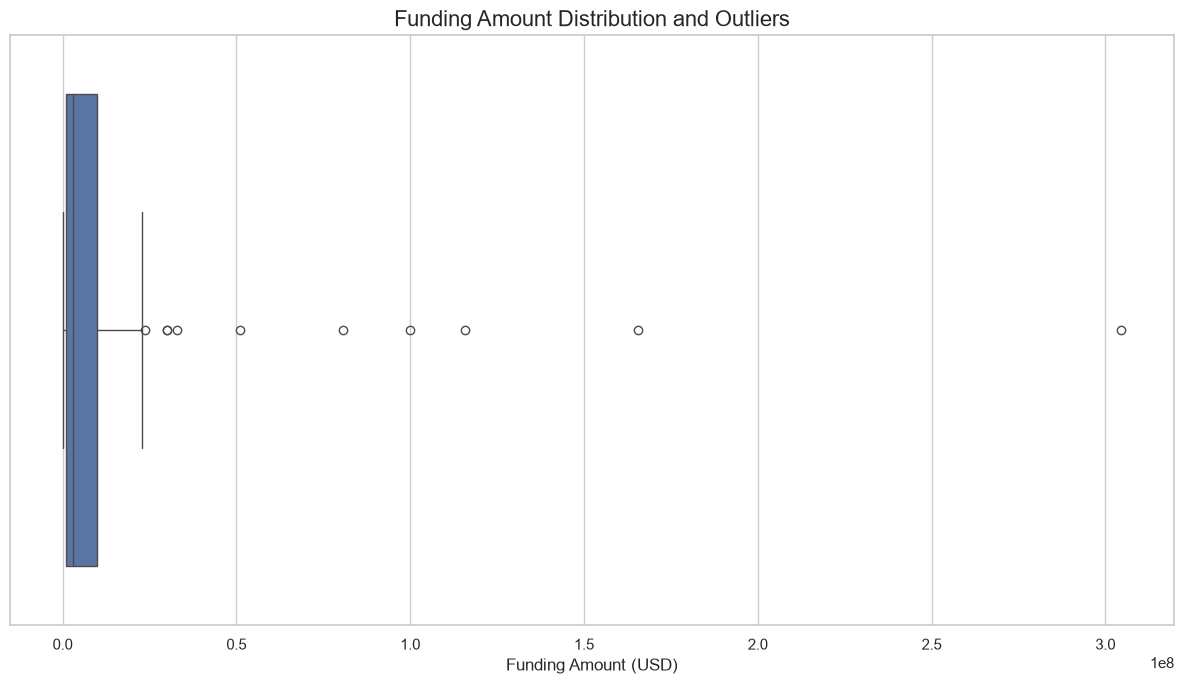

In [47]:
# ------------------------------------------------------------
# CHART 10 — FUNDING BOX PLOT
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

sns.boxplot(
    x=df["funding_amount"]
)

plt.title(
    "Funding Amount Distribution and Outliers",
    fontsize=16
)

plt.xlabel(
    "Funding Amount (USD)"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "10_funding_boxplot.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


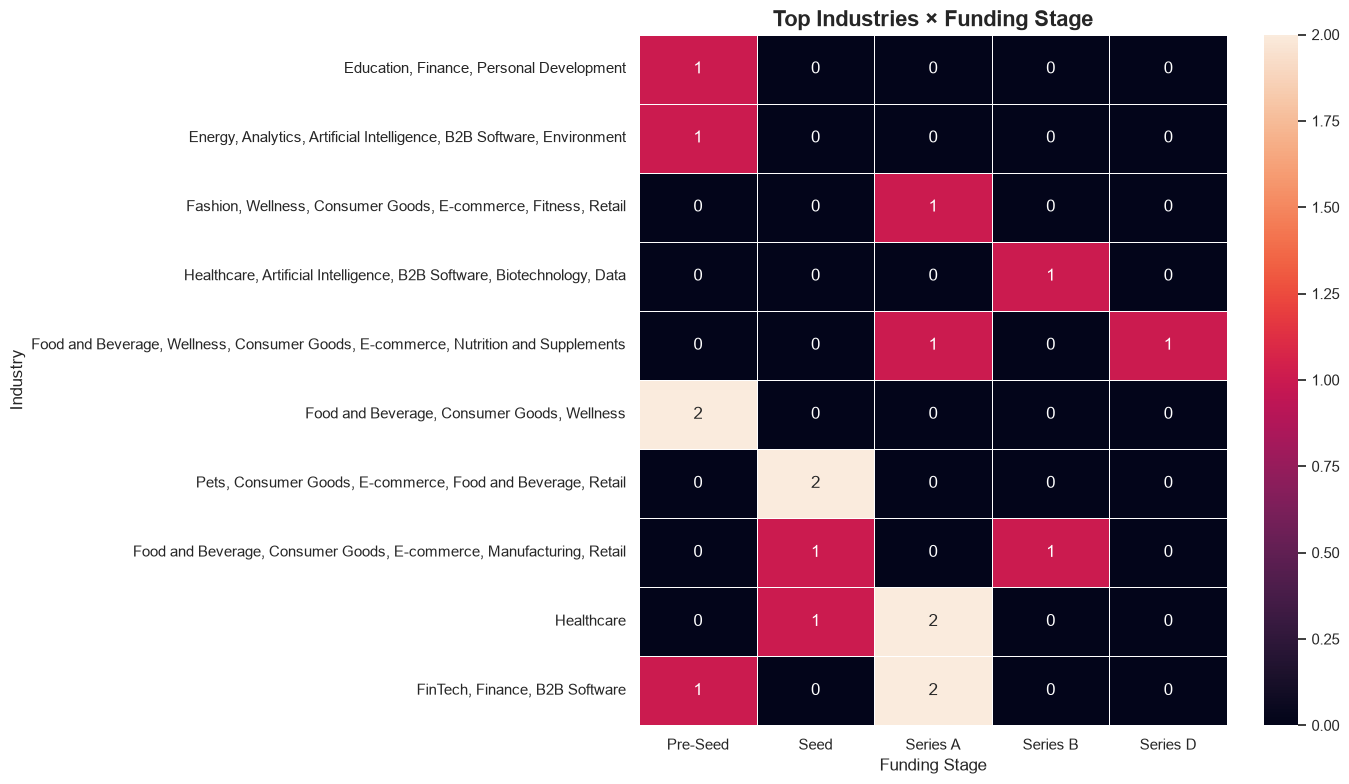

In [50]:
# ------------------------------------------------------------
# CHART 11 — FUNDING BY INDUSTRY AND STAGE
# ------------------------------------------------------------

# ------------------------------------------------------------
# STEP 1 — CREATE A CLEAN TEMPORARY DATAFRAME
# ------------------------------------------------------------

chart11_df = df[
    [
        "industry",
        "funding_type"
    ]
].copy()


# ------------------------------------------------------------
# STEP 2 — REMOVE MISSING VALUES
# ------------------------------------------------------------

chart11_df = chart11_df.dropna(
    subset=[
        "industry",
        "funding_type"
    ]
)


# ------------------------------------------------------------
# STEP 3 — FIND TOP 10 INDUSTRIES
# ------------------------------------------------------------

top_10_industries = (
    chart11_df["industry"]
    .value_counts()
    .head(10)
    .index
)


# ------------------------------------------------------------
# STEP 4 — FILTER TOP 10 INDUSTRIES
# ------------------------------------------------------------

chart11_df = chart11_df[
    chart11_df["industry"].isin(
        top_10_industries
    )
].copy()


# ------------------------------------------------------------
# STEP 5 — CREATE INDUSTRY × FUNDING STAGE TABLE
# ------------------------------------------------------------

heatmap_data = pd.crosstab(
    chart11_df["industry"],
    chart11_df["funding_type"]
)


# ------------------------------------------------------------
# STEP 6 — ORDER INDUSTRIES BY TOTAL STARTUP COUNT
# ------------------------------------------------------------

industry_order = (
    heatmap_data
    .sum(axis=1)
    .sort_values(ascending=True)
    .index
)

heatmap_data = heatmap_data.loc[
    industry_order
]


# ------------------------------------------------------------
# STEP 7 — PLOT HEATMAP
# ------------------------------------------------------------

plt.figure(
    figsize=(14, 8)
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    linewidths=0.5
)


# ------------------------------------------------------------
# STEP 8 — TITLES AND LABELS
# ------------------------------------------------------------

plt.title(
    "Top Industries × Funding Stage",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Funding Stage",
    fontsize=12
)

plt.ylabel(
    "Industry",
    fontsize=12
)


# ------------------------------------------------------------
# STEP 9 — DISPLAY
# ------------------------------------------------------------

plt.tight_layout()


# ------------------------------------------------------------
# STEP 10 — SAVE
# ------------------------------------------------------------

plt.savefig(
    os.path.join(
        CHART_DIR,
        "11_industry_stage_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

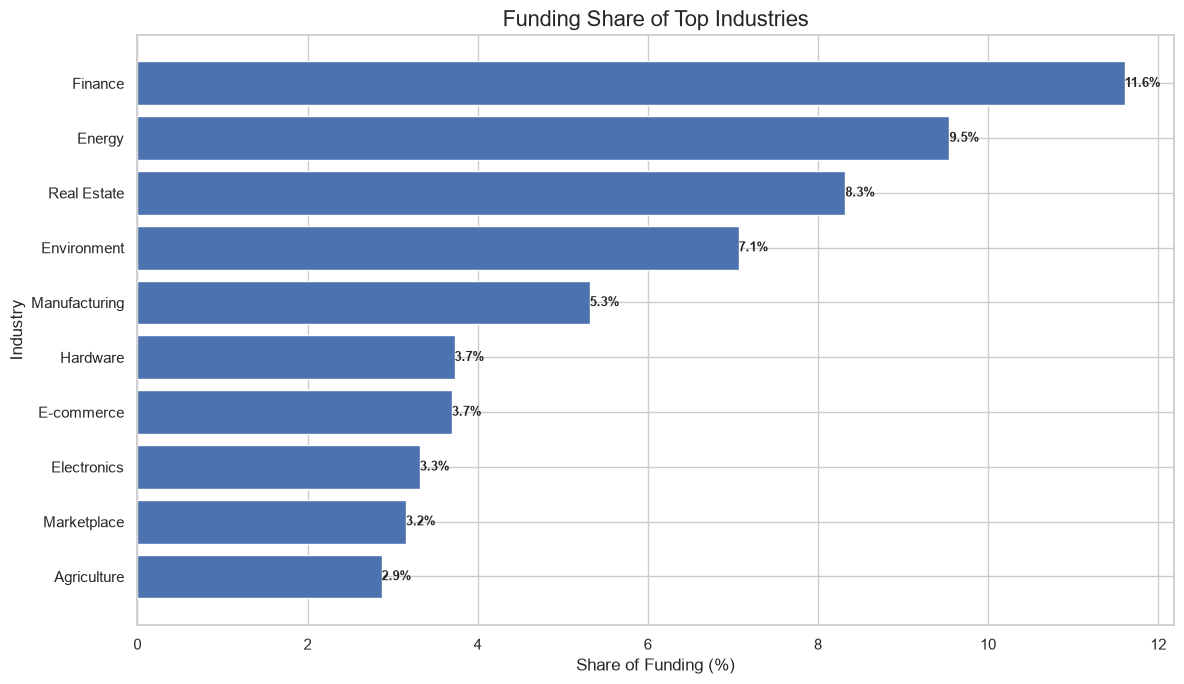

In [51]:
# ------------------------------------------------------------
# CHART 12 — FUNDING BY INDUSTRY SHARE
# ------------------------------------------------------------

share_plot = (
    industry_funding
    .head(10)
    .sort_values("Funding_Share_%")
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    share_plot.index,
    share_plot["Funding_Share_%"]
)

plt.title(
    "Funding Share of Top Industries",
    fontsize=16
)

plt.xlabel("Share of Funding (%)")
plt.ylabel("Industry")

# VALUE LABELS
for bar in bars:

    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_DIR,
        "12_industry_funding_share.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# AUTOMATED KEY INSIGHTS
# ============================================================



In [53]:
print("\n" + "=" * 70)
print("AUTOMATED KEY INSIGHTS")
print("=" * 70)



AUTOMATED KEY INSIGHTS


In [54]:
# ------------------------------------------------------------
# INSIGHT 1 — HIGHEST FUNDED STARTUP
# ------------------------------------------------------------

highest_funded = (
    df.dropna(
        subset=["funding_amount"]
    )
    .sort_values(
        "funding_amount",
        ascending=False
    )
    .iloc[0]
)

print(
    "\n1. Highest Funded Startup"
)

print(
    f"   {highest_funded['name']} "
    f"received ${highest_funded['funding_amount']:,.0f}."
)



1. Highest Funded Startup
   Aditya Birla Housing Finance received $304,527,929.


In [55]:
# ------------------------------------------------------------
# INSIGHT 2 — MOST COMMON FUNDING STAGE
# ------------------------------------------------------------

most_common_stage = (
    df["funding_type"]
    .value_counts()
    .idxmax()
)

stage_count = (
    df["funding_type"]
    .value_counts()
    .max()
)

print(
    "\n2. Most Common Funding Stage"
)

print(
    f"   {most_common_stage} "
    f"with {stage_count} startups."
)




2. Most Common Funding Stage
   Seed with 44 startups.


In [56]:
# ------------------------------------------------------------
# INSIGHT 3 — HIGHEST FUNDING STAGE
# ------------------------------------------------------------

highest_funding_stage = (
    funding_stage_analysis
    ["Total_Funding"]
    .idxmax()
)

highest_stage_amount = (
    funding_stage_analysis
    .loc[
        highest_funding_stage,
        "Total_Funding"
    ]
)

print(
    "\n3. Funding Stage Receiving the Most Capital"
)

print(
    f"   {highest_funding_stage} "
    f"with ${highest_stage_amount:,.0f}."
)



3. Funding Stage Receiving the Most Capital
   Private Equity with $705,091,478.


In [57]:
# ------------------------------------------------------------
# INSIGHT 4 — MOST REPRESENTED INDUSTRY
# ------------------------------------------------------------

most_common_industry = (
    industry_startups
    .idxmax()
)

industry_count = (
    industry_startups
    .max()
)

print(
    "\n4. Most Represented Industry"
)

print(
    f"   {most_common_industry} "
    f"appears across "
    f"{industry_count} startups."
)



4. Most Represented Industry
   Consumer Goods appears across 24 startups.


In [58]:
# ------------------------------------------------------------
# INSIGHT 5 — HIGHEST FUNDED INDUSTRY
# ------------------------------------------------------------

highest_industry = (
    industry_funding
    ["Total_Funding"]
    .idxmax()
)

highest_industry_funding = (
    industry_funding
    .loc[
        highest_industry,
        "Total_Funding"
    ]
)

print(
    "\n5. Highest Funded Industry"
)

print(
    f"   {highest_industry} "
    f"with ${highest_industry_funding:,.0f}."
)



5. Highest Funded Industry
   Finance with $475,263,666.


In [59]:
# ------------------------------------------------------------
# INSIGHT 6 — HIGHEST FUNDING MONTH
# ------------------------------------------------------------

if len(monthly_analysis) > 0:

    highest_month = (
        monthly_analysis
        .sort_values(
            "Total_Funding",
            ascending=False
        )
        .iloc[0]
    )

    print(
        "\n6. Highest Funding Month"
    )

    print(
        f"   {highest_month['funding_month_name']} "
        f"{int(highest_month['funding_year'])}: "
        f"${highest_month['Total_Funding']:,.0f}"
    )




6. Highest Funding Month
   February 2026: $1,101,885,533


In [60]:
# ------------------------------------------------------------
# INSIGHT 7 — MEDIAN VS AVERAGE
# ------------------------------------------------------------

print(
    "\n7. Funding Distribution Insight"
)

print(
    f"   Average funding: "
    f"${average_funding:,.0f}"
)

print(
    f"   Median funding: "
    f"${median_funding:,.0f}"
)

if average_funding > median_funding:

    print(
        "   The average exceeds the median, "
        "indicating that larger funding deals "
        "are pulling the average upward."
    )

elif average_funding < median_funding:

    print(
        "   The median exceeds the average, "
        "suggesting a distribution influenced "
        "by smaller funding observations."
    )


7. Funding Distribution Insight
   Average funding: $15,126,296
   Median funding: $3,000,000
   The average exceeds the median, indicating that larger funding deals are pulling the average upward.


In [61]:
# ------------------------------------------------------------
# INSIGHT 8 — FUNDING CONCENTRATION
# ------------------------------------------------------------

print(
    "\n8. Funding Concentration"
)

if total_funding > 0:

    print(
        f"   Top 10 startups represent "
        f"{top_10_share:.2f}% "
        f"of total recorded funding."
    )



8. Funding Concentration
   Top 10 startups represent 70.95% of total recorded funding.


In [62]:
# ------------------------------------------------------------
# INSIGHT 9 — MULTI-INDUSTRY STARTUPS
# ------------------------------------------------------------

multi_industry_percentage = (
    (df["industry_count"] > 1).mean()
    * 100
)

print(
    "\n9. Industry Diversification"
)

print(
    f"   {multi_industry_percentage:.2f}% "
    f"of startups are associated with "
    f"multiple industries."
)



9. Industry Diversification
   96.00% of startups are associated with multiple industries.


In [63]:
# ------------------------------------------------------------
# INSIGHT 10 — FUNDING DATA COMPLETENESS
# ------------------------------------------------------------

print(
    "\n10. Funding Data Completeness"
)

print(
    f"   {funding_coverage:.2f}% "
    f"of records contain a funding amount."
)



10. Funding Data Completeness
   87.00% of records contain a funding amount.


In [64]:
# ============================================================
# CREATE FINAL CLEAN DATASET
# ============================================================

clean_columns = [
    "name",
    "website",
    "industry",
    "country",
    "funding_amount",
    "funding_type",
    "last_funding_date",
    "funding_year",
    "funding_month",
    "funding_month_name",
    "funding_quarter",
    "industry_count"
]

clean_df = df[
    clean_columns
].copy()

clean_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "cleaned_startup_funding.csv"
    ),
    index=False
)


In [65]:
# ============================================================
# CREATE KPI SUMMARY FILE
# ============================================================

kpi_summary = pd.DataFrame({

    "Metric": [

        "Total Startups",
        "Total Funding",
        "Average Funding",
        "Median Funding",
        "Largest Funding",
        "Funding Coverage %",
        "Unique Industries",
        "Unique Funding Stages"

    ],

    "Value": [

        total_startups,
        total_funding,
        average_funding,
        median_funding,
        largest_funding,
        funding_coverage,
        df["industry"].nunique(),
        df["funding_type"].nunique()

    ]

})

kpi_summary.to_csv(
    os.path.join(
        TABLE_DIR,
        "kpi_summary.csv"
    ),
    index=False
)


In [66]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PROJECT COMPLETED")
print("=" * 70)

print(
    "\nOutput folder:"
)

print(
    os.path.abspath(OUTPUT_DIR)
)

print(
    "\nGenerated:"
)

print(
    "✓ Cleaned dataset"
)

print(
    "✓ KPI summary"
)

print(
    "✓ Data quality report"
)

print(
    "✓ Top startup analysis"
)

print(
    "✓ Funding stage analysis"
)

print(
    "✓ Industry analysis"
)

print(
    "✓ Monthly analysis"
)

print(
    "✓ Quarterly analysis"
)

print(
    "✓ Outlier analysis"
)

print(
    "✓ Funding concentration analysis"
)

print(
    "✓ 12 analytical charts"
)

print(
    "\nAll analysis completed successfully."
)


PROJECT COMPLETED

Output folder:
C:\Users\Nimesh\startup_analysis_output

Generated:
✓ Cleaned dataset
✓ KPI summary
✓ Data quality report
✓ Top startup analysis
✓ Funding stage analysis
✓ Industry analysis
✓ Monthly analysis
✓ Quarterly analysis
✓ Outlier analysis
✓ Funding concentration analysis
✓ 12 analytical charts

All analysis completed successfully.
